In [1]:
# installation of required packages - portallocker, torchtext, torchinfo,---
!pip -q install portalocker
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torchtext==0.15.2
!pip install -q torchinfo

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchdata 0.6.1 requires torch==2.0.1, but you have torch 2.5.1+cu118 which is incompatible.
torchtext 0.15.2 requires torch==2.0.1, but you have torch 2.5.1+cu118 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1+cu121 requires torch==2.5.1, but you have torch 2.0.1 which is incompatible.
torchvision 0.20.1+cu121 requires torch==2.5.1, but you have torch 2.0.1 which is incompatible.


In [1]:
from torchtext.datasets import AG_NEWS
train_data, test_data = AG_NEWS(split=('train', 'test'))

In [2]:
# Convert to list to get length
train_length = sum(1 for _ in train_data)
test_length = sum(1 for _ in test_data)

print("Train data length:", train_length)
print("Test data length:", test_length)

Train data length: 120000
Test data length: 7600


In [3]:
for i, sample in enumerate(train_data):
    if i == 3:  # Show only 3 samples
        break
    print(sample)  # Each sample is a tuple (label, text)

(3, "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.")
(3, 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.')
(3, "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.")


In [4]:
import nltk
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)

[nltk_data] Downloading package punkt to /home/guest/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/guest/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
import torchtext
import string
from torchtext.datasets import AG_NEWS
from torchtext.vocab import build_vocab_from_iterator
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchinfo import summary  # For displaying summary of model
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [6]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /home/guest/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import nltk
print(nltk.data.path)


['/home/guest/nltk_data', '/home/guest/miniconda/envs/mediapipe_env/nltk_data', '/home/guest/miniconda/envs/mediapipe_env/share/nltk_data', '/home/guest/miniconda/envs/mediapipe_env/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [8]:
ls -R /home/guest/nltk_data/tokenizers/


/home/guest/nltk_data/tokenizers/:
punkt/  punkt_tab/  punkt_tab.zip  punkt.zip

/home/guest/nltk_data/tokenizers/punkt:
czech.pickle     french.pickle     polish.pickle      spanish.pickle
danish.pickle    german.pickle     portuguese.pickle  swedish.pickle
dutch.pickle     greek.pickle      PY3/               turkish.pickle
english.pickle   italian.pickle    README
estonian.pickle  malayalam.pickle  russian.pickle
finnish.pickle   norwegian.pickle  slovene.pickle

/home/guest/nltk_data/tokenizers/punkt/PY3:
czech.pickle     finnish.pickle  malayalam.pickle   russian.pickle
danish.pickle    french.pickle   norwegian.pickle   slovene.pickle
dutch.pickle     german.pickle   polish.pickle      spanish.pickle
english.pickle   greek.pickle    portuguese.pickle  swedish.pickle
estonian.pickle  italian.pickle  README             turkish.pickle

/home/guest/nltk_data/tokenizers/punkt_tab:
czech/   english/   french/  italian/    polish/      russian/  swedish/
danish/  estonian/  german/  mal

In [8]:
import nltk
nltk.data.path.append('/home/guest/nltk_data')  # Ensure it looks in the right directory


In [9]:
import torch
import string
import nltk
from torchtext.datasets import AG_NEWS
from torchtext.vocab import build_vocab_from_iterator
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [10]:
nltk.data.path.append('/home/guest/nltk_data')
nltk.download('punkt', download_dir='/home/guest/nltk_data')
nltk.download('stopwords', download_dir='/home/guest/nltk_data')
nltk.download('punkt_tab', download_dir='/home/guest/nltk_data')

[nltk_data] Downloading package punkt to /home/guest/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/guest/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/guest/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [11]:

# Define stopwords and punctuation set
stop_words = set(stopwords.words('english'))
punctuations = set(string.punctuation)

# Load dataset and store it in lists
train_data = list(AG_NEWS(split='train'))
test_data = list(AG_NEWS(split='test'))

# Preprocessing function
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Tokenization & lowercase
    tokens = [word for word in tokens if word not in stop_words and word not in punctuations]  # Remove stopwords & punctuation
    return tokens

# Build vocabulary from training dataset
def yield_tokens(data_iter):
    for _, text in data_iter:
        yield preprocess_text(text)

# Reload dataset for iteration
train_data, test_data = AG_NEWS(split=('train', 'test'))
vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Numerical encoding function
def numericalize(text):
    return vocab(preprocess_text(text))

# Process dataset
processed_train = [(label, numericalize(text)) for label, text in train_data]
processed_test = [(label, numericalize(text)) for label, text in test_data]

# Show 3 samples
for i in range(3):
    print(processed_train[i])

(3, [335, 459, 1469, 14768, 59, 737, 5, 5, 51776, 335, 284, 2, 71033, 53355, 3864, 670])
(3, [15836, 954, 740, 1170, 4096, 5, 5, 808, 681, 232, 15836, 46, 27831, 4301, 461, 53874, 84504, 1990, 421, 167, 3739, 86755, 6424, 133, 269, 68])
(3, [21, 260, 4439, 89, 623, 5, 5, 2249, 353, 39, 1925, 27506, 260, 623, 188, 165, 53019, 209, 68, 58, 36, 7722, 40576, 15319])


In [27]:
import torch
import random

# Define max length and padding token
MAX_LEN = 256
PAD_TOKEN = 0  # Assuming the padding token index is 0

# Combine train and test sets
full_data = processed_train
random.shuffle(full_data)  # Shuffle before splitting

# Split training dataset: 80% train, 20% validation
train_size = int(0.8 * len(full_data))
val_size = int(0.2 * len(full_data))

train_data = full_data[:train_size]
val_data = full_data[train_size:]
test_data = processed_test[:]

# Function to apply padding
def pad_sequence(seq, max_len=MAX_LEN):
    seq = torch.tensor(seq) if not isinstance(seq, torch.Tensor) else seq  # Ensure tensor
    if len(seq) < max_len:
        seq = torch.cat([seq, torch.full((max_len - len(seq),), PAD_TOKEN, dtype=torch.long)])
    else:
        seq = seq[:max_len]
    return seq

# Apply padding
processed_train = [(label, pad_sequence(text)) for label, text in train_data]
processed_val = [(label, pad_sequence(text)) for label, text in val_data]
processed_test = [(label, pad_sequence(text)) for label, text in test_data]

# Show 3 samples
for i in range(3):
    print(processed_train[i])

(3, tensor([  969,     2,    54, 16973,  2775,   167, 32659,     3,    29,     5,
         1723,   222,     8,   177,    10,   166,  2386, 14604,  2391,  2388,
         2390,    10,     7, 11117,     8,   178,     7,   570,    91,  7022,
           26,    36,  2710,   779,  9499,    13,  2842,   325,  1539,   110,
          147,  2041,    43,  4490,  3249,  1937,  1386,    65,   194, 15857,
           13,    45,   261,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,    

In [13]:
# Extract labels from all datasets
all_labels = {label for label, _ in processed_train} | \
             {label for label, _ in processed_val} | \
             {label for label, _ in processed_test}

# Print unique labels
print("Unique labels:", all_labels)

Unique labels: {1, 2, 3, 4}


In [15]:
# Function to re-encode labels
def encode_label(label):  # Convert 1 → 0 , 2 → 1 ,  3 → 2 , 4 → 3

        if label == 1:
            return 0
        elif label == 2:
            return 1
        elif label == 3:
            return 2
        elif label == 4:
            return 3
        else:
            return -1  # or raise an error for unexpected labels
# Apply label encoding
processed_train = [(encode_label(label), text) for label, text in processed_train]
processed_val = [(encode_label(label), text) for label, text in processed_val]
processed_test = [(encode_label(label), text) for label, text in processed_test]

# Verify unique labels after encoding
all_labels = {label for label, _ in processed_train} | \
             {label for label, _ in processed_val} | \
             {label for label, _ in processed_test}

print("Unique labels after encoding:", all_labels)

Unique labels after encoding: {0, 1, 2, 3}


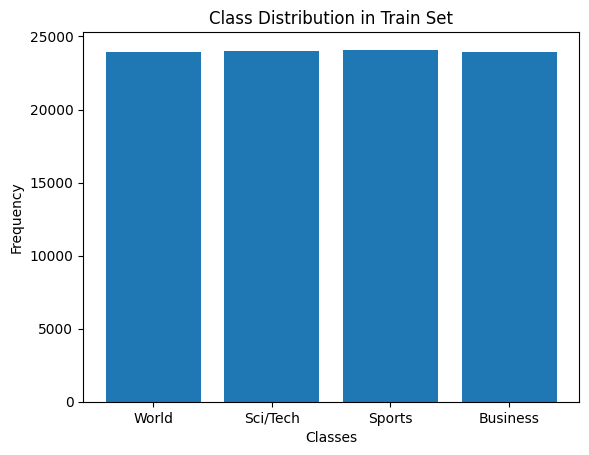

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

# Count occurrences of each class
def plot_class_distribution(data, title):
    labels = [label for label, _ in data]
    class_counts = Counter(labels)

    plt.bar(class_counts.keys(), class_counts.values(), tick_label=["World", "Sports", "Business", "Sci/Tech"])
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# Plot for train and validation sets
plot_class_distribution(train_data, "Class Distribution in Train Set")


In [16]:
# Hyperparameters
EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
NUM_CLASSES = 4  # Since we have labels {0,1}
BATCH_SIZE = 32
DROPOUT_PROB=0.25
EPOCHS = 8
VOCAB_SIZE = len(vocab)  # Vocabulary size

In [17]:
VOCAB_SIZE

99981

In [18]:
import torch
import torch.nn as nn

# Define GRU Model with Two Layers using nn.GRUCell
class GRUCell(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout_prob):
        super(GRUCell, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru1 = nn.GRUCell(embedding_dim, hidden_dim)
        self.gru2 = nn.GRUCell(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        h1 = torch.zeros(x.size(0), self.gru1.hidden_size, device=x.device)
        h2 = torch.zeros(x.size(0), self.gru2.hidden_size, device=x.device)

        for i in range(x.size(1)):  # Iterate over sequence length
            h1 = self.gru1(embedded[:, i, :], h1)
            h1 = self.dropout(h1)
            h2 = self.gru2(h1, h2)

        return self.fc(h2)


In [19]:
# Convert data to tensors
from torch.utils.data import DataLoader, TensorDataset

def create_dataloader(processed_data, batch_size):
    labels = torch.tensor([label for label, _ in processed_data], dtype=torch.long)
    sequences = torch.stack([text for _, text in processed_data])  # Stack tensors
    dataset = TensorDataset(sequences, labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create DataLoaders
train_loader = create_dataloader(processed_train, BATCH_SIZE)
val_loader = create_dataloader(processed_val, BATCH_SIZE)
test_loader = create_dataloader(processed_test, BATCH_SIZE)

In [20]:
# Define model, loss, and optimizer
vocab_size = len(vocab)  # Change this based on your vocab size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
device

device(type='cuda')

In [23]:
model = GRUCell(vocab_size, EMBED_DIM, HIDDEN_DIM,NUM_CLASSES,DROPOUT_PROB).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [24]:
print(model)

GRUCell(
  (embedding): Embedding(99981, 128)
  (gru1): GRUCell(128, 256)
  (gru2): GRUCell(256, 256)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


In [25]:

import matplotlib.pyplot as plt

# Training loop with loss visualization
def train_model(model, train_loader, val_loader, epochs):
    model.train()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        total_train_loss = 0
        model.train()  # Ensure model is in training mode

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Compute validation loss
        model.eval()  # Switch to evaluation mode
        total_val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

        # Calculate average loss
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    print("Training complete.")

    # Plot loss variation
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
    plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training & Validation Loss Over Epochs")
    plt.show()



Epoch [1/8], Train Loss: 1.3911, Val Loss: 1.3876
Epoch [2/8], Train Loss: 1.3054, Val Loss: 0.6608
Epoch [3/8], Train Loss: 0.3596, Val Loss: 0.2704
Epoch [4/8], Train Loss: 0.2416, Val Loss: 0.2569
Epoch [5/8], Train Loss: 0.2150, Val Loss: 0.2793
Epoch [6/8], Train Loss: 0.2016, Val Loss: 0.2769
Epoch [7/8], Train Loss: 0.1963, Val Loss: 0.2840
Epoch [8/8], Train Loss: 0.1846, Val Loss: 0.2941
Training complete.


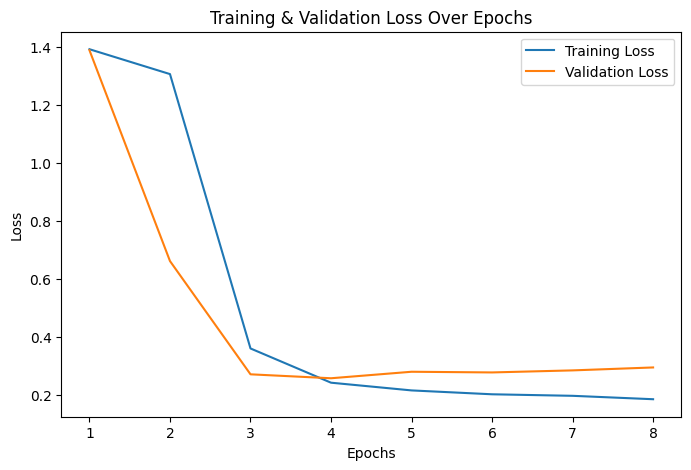

In [26]:
# Train the model
train_model(model, train_loader, val_loader, EPOCHS)

In [28]:
# Fetch one batch from train_loader
actual_input, _ = next(iter(train_loader))  # Get batch_x (ignore batch_y)

# Ensure the input is of type LongTensor
actual_input = actual_input.to(dtype=torch.long, device=device)

# Display model summary
summary(model, input_data=actual_input, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
GRUCell                                  [32, 256]                 [32, 4]                   --                        True
├─Embedding: 1-1                         [32, 256]                 [32, 256, 128]            12,797,568                True
├─GRUCell: 1-2                           [32, 128]                 [32, 256]                 296,448                   True
├─Dropout: 1-3                           [32, 256]                 [32, 256]                 --                        --
├─GRUCell: 1-4                           [32, 256]                 [32, 256]                 394,752                   True
├─GRUCell: 1-5                           [32, 128]                 [32, 256]                 (recursive)               True
├─Dropout: 1-6                           [32, 256]                 [32, 256]                 --                        --
├─GRUCe

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate model performance
def evaluate_model(model, data_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []   # initializing the lists
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)

            # Store predictions and actual labels
            all_preds.extend(predicted.cpu().tolist())  # Use .tolist()
            all_labels.extend(batch_y.cpu().tolist())

            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    # Compute accuracy
    accuracy = correct / total

    # Compute precision, recall, and F1-score
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("Confusion Matrix:\n", conf_matrix)

# Evaluate on test set
evaluate_model(model, test_loader)


Accuracy:  0.9021
Precision: 0.9036
Recall:    0.9021
F1-score:  0.9024
Confusion Matrix:
 [[1770   21   66   43]
 [  92 1753   41   14]
 [  70    6 1662  162]
 [  86   12  131 1671]]


In [30]:
import torch
import torch.nn as nn

# Define GRU Model with Two Layers using nn.GRU
class GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout_prob):
        super(GRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru1 = nn.GRU(embedding_dim, hidden_dim, batch_first=True) 
        self.gru2 = nn.GRU(hidden_dim, hidden_dim, batch_first=True) 
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        h1 = torch.zeros(1, x.size(0), self.gru1.hidden_size, device=x.device)  
        out, _ = self.gru1(embedded, h1)  
        out = self.dropout(out)
        h2 = torch.zeros(1, x.size(0), self.gru2.hidden_size, device=x.device) 
        out, _ = self.gru2(out, h2)  
        # Take the last hidden state
        out = out[:, -1, :] 
        return self.fc(out)

In [31]:
model1 = GRU(vocab_size, EMBED_DIM, HIDDEN_DIM,NUM_CLASSES,DROPOUT_PROB).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-5)

In [32]:
print(model1)

GRU(
  (embedding): Embedding(99981, 128)
  (gru1): GRU(128, 256, batch_first=True)
  (gru2): GRU(256, 256, batch_first=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


In [34]:
EPOCHS1=5

Epoch [1/5], Train Loss: 1.3883, Val Loss: 1.3878
Epoch [2/5], Train Loss: 1.0598, Val Loss: 0.3145
Epoch [3/5], Train Loss: 0.2391, Val Loss: 0.2370
Epoch [4/5], Train Loss: 0.1635, Val Loss: 0.2385
Epoch [5/5], Train Loss: 0.1207, Val Loss: 0.2593
Training complete.


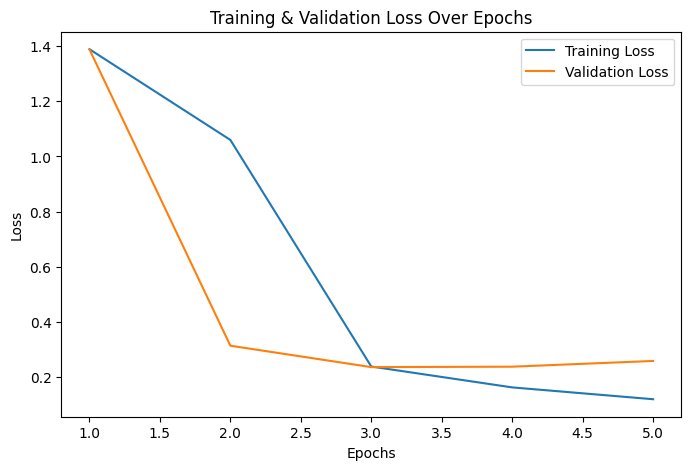

In [35]:
# Train the model
train_model(model1, train_loader, val_loader, EPOCHS1)

In [36]:
# Evaluate on test set
evaluate_model(model1, test_loader)

Accuracy:  0.8855
Precision: 0.8919
Recall:    0.8855
F1-score:  0.8864
Confusion Matrix:
 [[1778   21   51   50]
 [ 222 1654   16    8]
 [ 113    6 1617  164]
 [ 105   10  104 1681]]


In [37]:
# Display model summary
summary(model1, input_data=actual_input, col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
GRU                                      [32, 256]                 [32, 4]                   --                        True
├─Embedding: 1-1                         [32, 256]                 [32, 256, 128]            12,797,568                True
├─GRU: 1-2                               [32, 256, 128]            [32, 256, 256]            296,448                   True
├─Dropout: 1-3                           [32, 256, 256]            [32, 256, 256]            --                        --
├─GRU: 1-4                               [32, 256, 256]            [32, 256, 256]            394,752                   True
├─Linear: 1-5                            [32, 256]                 [32, 4]                   1,028                     True
Total params: 13,489,796
Trainable params: 13,489,796
Non-trainable params: 0
Total mult-adds (G): 6.07
Input size (MB): 0.07
For